<a href="https://colab.research.google.com/github/DanuAlamsyah/Pengolahan-Citra/blob/main/Tugas4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Praktikum 1. Segmentasi Menggunakan Thresholding Global dan Otsu

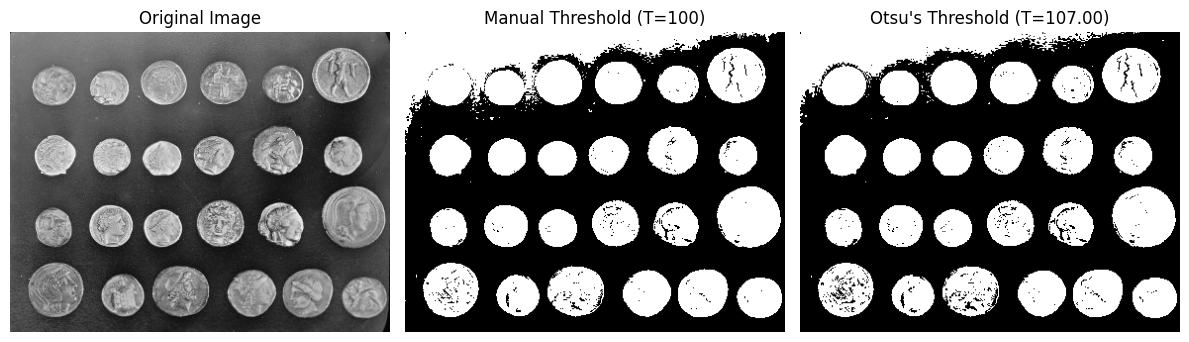

Nilai threshold Otsu ditemukan: 107


In [2]:
import matplotlib.pyplot as plt
from skimage import data, filters, img_as_ubyte
from skimage.color import rgb2gray

#1. membuat citra (Coin)
image_coins = data.coins() #udah greyscale

#2. thresholding global (Manual)
#Menentukan nilai ambang manual, saya ambil 100
thresh_manual = 100
binary_manual = image_coins > thresh_manual

#3.thresholding otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

#4.visualisasi hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f'Otsu\'s Threshold (T={thresh_otsu:.2f})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

#Menampilkan nilai threshold Otsu
print(f"Nilai threshold Otsu ditemukan: {thresh_otsu}")



Praktikum 2. Segmentasi Menggunakan Region Growing (Contoh Sederhana)

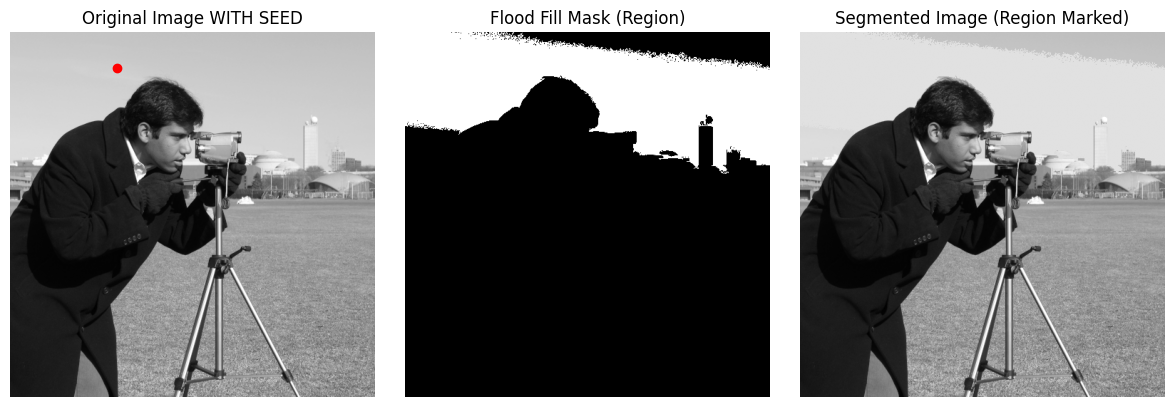

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color
#1.membuat citra(camera)
image_camera = data.camera()

#2.menentukan titik 'seed' (benih)
#pilih titik di area langit (misal, koordinat y=50, x=150)
seed_point = (50, 150)

#3.Terapkan algoritma flood fill  (mirip regional growing)
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

#4.buat citra tersegmentasi(tandai regional yang tumbuh)
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 225 #tandai dgn warna putih

#5.visualisasi hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap=plt.cm.gray)
ax[0].plot(seed_point[1], seed_point[0], 'ro')
ax[0].set_title('Original Image WITH SEED')
ax[0].axis('off')



ax[1].imshow(flood_mask, cmap=plt.cm.gray)
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap=plt.cm.gray)
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

Praktikum 3. Segmentasi Citra Berwarna Menggunakan K-Means Clustering

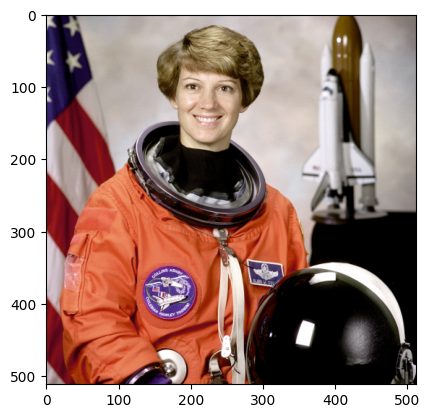

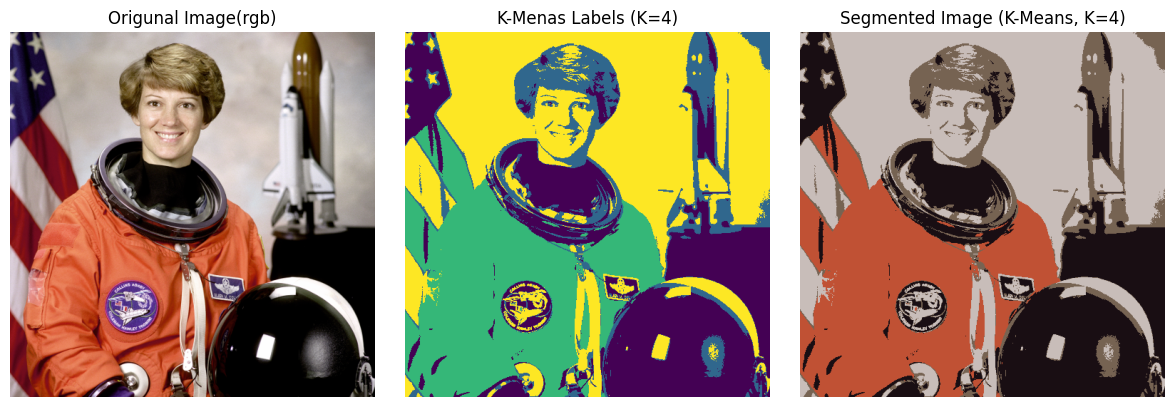

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

#1.membuat citra berwarna (astronout)
image_astro = data.astronaut()
plt.imshow(image_astro)
#konversi ke float
image_astro_float = image_astro.astype(float) / 255.0

#2.reshape citra menjadi array piksel [jumlah_piksel, jumlah_fitur]
#fitur bisa RGB ata Lab. Ruangan warna Lab seringkali lebih baik untuk persepsi warna
#konversi ke lab
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

#3.terapkan KMeans Clustering
#tentukan jumlah klaster (segmen) yang diinginkan, misal k=4
n_clusters = 4
kmeans = KMeans(n_clusters=n_cluster, random_state=0, n_init=10)
#n_init='auto'jika sklearn baru

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

#4.reshape label kembali ke bentuk citra
segmented_labels = pixel_labels.reshape(rows, cols)

#5.buat citra tersegmentasi (warnai setiap segmen dengan warna rata klaster)
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_
for k in range(n_clusters):
    #dapatkan pixel termasuk klaster k
    cluster_pixels = (pixel_labels == k)
    #isi piksel tersebut di citra baru
    #perlu reshape kembali cluster_pixels ke bentuk citra
    mask_k = cluster_pixels.reshape(rows, cols)
    segmented_image_kmeans[mask_k] = centers_lab[k]

#konversi rgb kembali
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

#6.visualisasi hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Origunal Image(rgb)')
ax[0].axis('off')

#label klaster
ax[1].imshow(segmented_labels, cmap='viridis') # cmap bisa diganti
ax[1].set_title(f'K-Menas Labels (K={n_clusters})')
ax[1].axis('off')

#citra hasil segmentasi KMeans
ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

Praktikum 4. Segmentasi Berbasis Tepi Menggunakan Watershed

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, morphology, measure
from scipy import ndimage as ndi

#1.membuat citra (coins)
image_coins = data.coins()

#2.hitung gradien citra (topografi)
elevation_map = filters.sobel(image_coins)

#3.
